# Final Notebook - Classifying Spam Emails

Notebook cuối này tổng hợp toàn bộ nội dung từ các notebook `00` đến `06`, các báo cáo trong `reports/`, các ảnh đánh giá đã train trong `reports/figures/`, và phần giao diện kiểm tra spam của project.

Mục tiêu của notebook:

- Tóm tắt bài toán phân loại email spam/not spam.
- Trình bày nguồn dữ liệu, EDA, tiền xử lý, feature engineering và cân bằng dữ liệu.
- So sánh Naive Bayes, Logistic Regression và Linear SVM bằng metric, confusion matrix và learning curve.
- Giải thích vì sao chọn model cuối cùng.
- Demo dự đoán email mới và ghi lại cách chạy giao diện web local.


## 0. Nội dung được tổng hợp

| Notebook/File gốc | Nội dung được tổng hợp vào notebook cuối |
| --- | --- |
| `00_problem_definition.ipynb` | Bối cảnh, mục tiêu, phạm vi, tiêu chí thành công |
| `01_data_collection.ipynb` | Nguồn dữ liệu, nguồn chính thống/tham khảo, schema dữ liệu |
| `02_eda.ipynb` | Biểu đồ phân bố nhãn và phân bố độ dài email |
| `03_data_preprocessing.ipynb` | Quy trình làm sạch text và chuẩn hóa dữ liệu |
| `04_test_feature.ipynb` | Kiểm thử feature engineering và đặc trưng văn bản |
| `05_training_and_evaluation.ipynb` | Kết quả train, learning curve, confusion matrix, demo predict |
| `06_model_comparison_charts.ipynb` | Bar chart so sánh metric và grid confusion matrix |
| `reports/*.json/csv/txt` | Số liệu thật sau khi chạy pipeline |
| `app.py`, `templates/` | Giao diện Flask kiểm tra email spam/not spam |

Các ảnh trong notebook là ảnh đã train/đánh giá hoặc ảnh output được trích lại từ notebook gốc, không phải ảnh mẫu minh họa.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_SOURCES_DIR = PROJECT_ROOT / 'data_sources'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
SAMPLE_EMAILS_DIR = PROJECT_ROOT / 'sample_emails'

print('Project root:', PROJECT_ROOT)
print('Reports exists:', REPORTS_DIR.exists())
print('Figures exists:', FIGURES_DIR.exists())
print('Models exists:', MODELS_DIR.exists())


Project root: c:\Users\User\OneDrive - ut.edu.vn\Documents\Machine Learning - Trường\Project-Classifying-Spam-Emails-final-review
Reports exists: True
Figures exists: True
Models exists: True


## 1. Problem Definition

Bài toán: xây dựng hệ thống phân loại email thành 2 lớp:

- `0`: not spam / ham
- `1`: spam

Input là nội dung email dạng text. Output là nhãn dự đoán `spam` hoặc `not spam`, kèm `spam_score` và các dấu hiệu văn bản ảnh hưởng tới kết quả.

Ý nghĩa thực tế:

- Giảm lượng email rác, quảng cáo độc hại, lừa đảo hoặc email gây phiền nhiễu.
- Hỗ trợ người dùng lọc email tự động thay vì kiểm tra thủ công.
- Ưu tiên phát hiện spam tốt nhưng vẫn hạn chế chặn nhầm email tốt.


## 2. Success Metrics

Với spam detection, nhóm không chỉ nhìn accuracy vì accuracy cao vẫn có thể che giấu lỗi chặn nhầm hoặc bỏ sót spam. Các metric chính:

| Metric | Ý nghĩa | Vì sao quan trọng |
| --- | --- | --- |
| Accuracy | Tỷ lệ dự đoán đúng trên toàn bộ test set | Cho cái nhìn tổng quát |
| Precision spam | Trong các email bị dự đoán là spam, bao nhiêu email thật sự là spam | Giảm chặn nhầm email tốt |
| Recall spam | Trong các email spam thật, model bắt được bao nhiêu | Giảm bỏ sót email nguy hiểm |
| F1 spam | Trung hòa precision và recall | Dùng để chọn model cân bằng |
| False positive | Email tốt bị đánh nhầm là spam | Cần thấp để không mất email quan trọng |
| False negative | Email spam bị đánh nhầm là not spam | Cần thấp để tránh spam lọt qua |


## 3. Data Collection

Nguồn dữ liệu chính của project:

| Nguồn | Vai trò |
| --- | --- |
| SpamAssassin Public Corpus | Nguồn ham/spam public, có nhãn rõ |
| SetFit Enron Spam | Dataset email spam/ham từ Hugging Face |
| locuoco 300k spam/ham/phish | Dataset lớn, map spam/phish về class spam |
| TREC Spam Track | Nguồn chính thống để tham khảo thêm |
| CMU Enron Email Dataset | Nguồn email Enron chính thống, cần gán nhãn cẩn thận nếu mở rộng |

Project chuẩn hóa dữ liệu về schema:

```text
source,file_name,label,label_name,subject,text
```


In [2]:
source_path = DATA_SOURCES_DIR / 'data_links.csv'
if source_path.exists():
    sources = pd.read_csv(source_path)
    display(sources)
else:
    print('Không tìm thấy data_sources/data_links.csv')


,source_name,url,source_type,official_status,usage_in_project,note
0,SpamAssassin Public Corpus,https://spamassassin.apache.org/old/publiccorpus/,Official Apache SpamAssassin archive,official,used,Contains public ham/spam archives used by src/...
1,SetFit enron_spam,https://huggingface.co/datasets/SetFit/enron_spam,Hugging Face dataset page,community_hosted_on_huggingface,used,33.7k labeled ham/spam dataset; downloaded as ...
2,locuoco 300k spam ham phish,https://huggingface.co/datasets/locuoco/the-bi...,Hugging Face dataset page,community_hosted_on_huggingface,used,Large labeled text dataset; original phish/spa...
3,TREC Spam Track,https://trec.nist.gov/data/spam.html,NIST TREC data page,official,reference_only,Official TREC page for spam corpora; useful if...
4,CMU Enron Email Dataset,https://www.cs.cmu.edu/~enron/,CMU dataset page,official,reference_only,Official CMU-hosted Enron email dataset; mostl...


## 4. Data Loading và cân bằng dữ liệu

Sau khi tải/gộp dữ liệu, pipeline tạo các file processed gồm bản labeled và bản balanced. Việc cân bằng giúp số email spam và not spam ngang nhau trước khi train, tránh model học lệch về class có số lượng lớn hơn.

Số liệu chính từ report hiện tại:

| Giai đoạn | Số dòng | Not spam | Spam | Ghi chú |
| --- | ---: | ---: | ---: | --- |
| Combined labeled | 315,668 | 148,098 | 167,570 | Dữ liệu đã gộp từ nhiều nguồn |
| Combined balanced | 296,196 | 148,098 | 148,098 | Đã cân bằng 2 lớp |
| Clean balanced | 294,718 | 147,359 | 147,359 | Sau khi lọc lỗi/ngắn |

Nguồn đóng góp nhiều nhất là dataset locuoco 300k, sau đó là SetFit Enron Spam và SpamAssassin.


In [3]:
loader_report_path = REPORTS_DIR / 'data_loader_report.json'
quality_report_path = REPORTS_DIR / 'data_quality_report.json'

for report_path in [loader_report_path, quality_report_path]:
    print('\n---', report_path.name, '---')
    if report_path.exists():
        payload = json.loads(report_path.read_text(encoding='utf-8'))
        print(json.dumps(payload, indent=2, ensure_ascii=False))
    else:
        print('Không tìm thấy file report:', report_path)



--- data_loader_report.json ---
{
  "spamassassin_labeled": {
    "row_count": 5903,
    "label_counts": {
      "0": 4112,
      "1": 1791
    },
    "invalid_label_count": 0,
    "empty_text_count": 0,
    "short_text_count": 3,
    "duplicate_text_count": 0,
    "is_valid": true
  },
  "spamassassin_balanced": {
    "row_count": 3582,
    "label_counts": {
      "0": 1791,
      "1": 1791
    },
    "invalid_label_count": 0,
    "empty_text_count": 0,
    "short_text_count": 3,
    "duplicate_text_count": 0,
    "is_valid": true
  },
  "combined_labeled": {
    "row_count": 315668,
    "label_counts": {
      "0": 148098,
      "1": 167570
    },
    "invalid_label_count": 0,
    "empty_text_count": 0,
    "short_text_count": 1252,
    "duplicate_text_count": 10,
    "is_valid": true
  },
  "combined_balanced": {
    "row_count": 296196,
    "label_counts": {
      "0": 148098,
      "1": 148098
    },
    "invalid_label_count": 0,
    "empty_text_count": 0,
    "short_text_count":

## 5. EDA - Phân tích dữ liệu

Phần EDA được lấy từ `02_eda.ipynb`. Hai biểu đồ dưới đây cho thấy phân bố nhãn và phân bố độ dài email trong dữ liệu.

![Phân bố nhãn spam/ham](../reports/figures/eda_label_distribution.png)

![Phân bố độ dài email theo loại](../reports/figures/eda_email_length_distribution.png)

Nhận xét:

- Phân bố nhãn giúp kiểm tra dữ liệu có bị lệch giữa spam và not spam hay không.
- Phân bố độ dài giúp quan sát email spam/not spam có khác nhau về độ dài văn bản hay không.
- EDA hỗ trợ quyết định cần cân bằng dữ liệu, lọc dòng quá ngắn và chuẩn hóa text trước khi train.


## 6. Data Quality

Pipeline kiểm tra chất lượng dữ liệu theo các nhóm lỗi chính:

- Label không hợp lệ.
- Text rỗng.
- Text quá ngắn.
- Dòng trùng lặp theo `label` + `text`.

Report hiện tại cho thấy dataset balanced ban đầu có 296,196 dòng. Sau khi lọc lỗi còn 294,718 dòng, tức loại 1,478 dòng. Hai class vẫn cân bằng: 147,359 not spam và 147,359 spam.


In [4]:
issues_path = REPORTS_DIR / 'data_quality_issues.csv'
if issues_path.exists():
    issues = pd.read_csv(issues_path)
    print('Số dòng lỗi được ghi nhận:', len(issues))
    display(issues.head(10))
else:
    print('Không tìm thấy reports/data_quality_issues.csv')


Số dòng lỗi được ghi nhận: 1156


,issue,row_index,source,file_name,label,label_name,text
0,short_text,50,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,"phelim ,\r\nfyi\r\nvince"
1,short_text,453,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,kevin kindall
2,short_text,497,locuoco_big_spam_ham_phish_300k,0001.parquet,0,ham,look
3,short_text,521,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,buenos noches g'bye
4,short_text,587,locuoco_big_spam_ham_phish_300k,0001.parquet,0,ham,go new york tonight
5,short_text,1002,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,hi try nothing
6,short_text,1418,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,basvsehp jy e snd
7,short_text,1434,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,dont like beth
8,short_text,1482,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,maxine
9,short_text,1563,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,hurricane elana


## 7. Preprocessing

Module chính: `src/text_preprocess.py`.

Các bước xử lý text:

- Xóa HTML, script, style.
- Chuẩn hóa URL thành `urltoken`.
- Chuẩn hóa email address thành `emailtoken`.
- Chuẩn hóa số thành `numbertoken`.
- Chuyển về lowercase.
- Loại ký tự đặc biệt dư thừa.
- Loại stopwords tiếng Anh nếu có NLTK corpus; dùng fallback nếu thiếu.

Mục tiêu là làm email về dạng sạch, giảm nhiễu, nhưng vẫn giữ lại các dấu hiệu quan trọng như URL, email address, số tiền hoặc pattern lặp lại trong spam.


In [5]:
from src.text_preprocess import clean_email_text

examples = [
    '<html>FREE prize!!! Click https://spam.example now, contact test@example.com for 100 dollars</html>',
    'Hi team, please confirm tomorrow meeting agenda and send the project report when ready.',
]

for text in examples:
    print('RAW:', text)
    print('CLEAN:', clean_email_text(text))
    print()


RAW: <html>FREE prize!!! Click https://spam.example now, contact test@example.com for 100 dollars</html>
CLEAN: free prize click urltoken contact emailtoken numbertoken dollars

RAW: Hi team, please confirm tomorrow meeting agenda and send the project report when ready.
CLEAN: hi team please confirm tomorrow meeting agenda send project report ready



## 8. Feature Engineering

Feature engineering là bước chuyển email text thành vector số để model học được.

Project dùng hướng chính:

| Feature | Vai trò |
| --- | --- |
| TF-IDF unigram/bigram | Biểu diễn từ/cụm từ quan trọng trong email |
| URL token | Giữ dấu hiệu có link trong email |
| Email token | Giữ dấu hiệu có địa chỉ email |
| Number token | Giữ dấu hiệu số tiền, mã, con số quảng cáo |
| Từ khóa/cụm từ spam | Những term có trọng số cao hỗ trợ giải thích dự đoán |

Trong báo cáo feature cũ, nhóm cũng có phân tích manual features như độ dài email, số URL, số dấu `!`, số ký tự `$`, tỷ lệ chữ in hoa. Các feature này hữu ích để giải thích spam, dù pipeline train cuối đang ưu tiên TF-IDF để đơn giản và ổn định.


In [6]:
feature_report_path = REPORTS_DIR / 'feature_report.txt'
if feature_report_path.exists():
    feature_text = feature_report_path.read_text(encoding='utf-8', errors='replace')
    print(feature_text[:2000])
else:
    print('Không tìm thấy reports/feature_report.txt')


BÁO CÁO FEATUBÁO CÁO FEATURE ENGINEERING
Người thực hiện: Nhật Trung

1. Giới thiệu
Feature Engineering là bước chuyển đổi dữ liệu email thô thành các đặc trưng số để máy học có thể hiểu và học được.

2. Các feature đã xây dựng

2.1 TF-IDF Features
- Dùng để chuyển nội dung email thành vector số dựa trên tần suất xuất hiện của từ
- Tham số: max_features=5000, ngram_range=(1,2), stop_words='english', lowercase=True

2.2 Manual Features (feature thủ công)
- length: độ dài email
- url_count: số lượng URL trong email
- exclamation_count: số dấu !
- dollar_count: số ký tự $
- uppercase_ratio: tỷ lệ chữ in hoa / tổng số chữ

3. Kết quả đạt được
- Chỉ dùng TF-IDF: độ chính xác 96.8%
- Dùng TF-IDF + Manual features: độ chính xác 97.2%
- Kết luận: Thêm manual features giúp tăng độ chính xác thêm 0.4%

4. Kết luận chung
- Feature Engineering rất quan trọng cho bài toán phân loại spam
- Kết hợp TF-IDF và manual features cho kết quả tốt nhất 97.2%
- Các feature như URL, dấu !, tỷ lệ chữ hoa giúp n

## 9. Model Training

Model được train bằng pipeline:

```text
TfidfVectorizer(max_features=25000, ngram_range=(1, 2), stop_words='english')
-> classifier
```

Ba model được so sánh:

| Model | Điểm mạnh | Điểm yếu |
| --- | --- | --- |
| Multinomial Naive Bayes | Nhanh, hợp với dữ liệu text sparse, dễ baseline | Giả định độc lập giữa các từ nên có thể kém hơn khi pattern phức tạp |
| Logistic Regression | Cân bằng tốt giữa tốc độ, độ chính xác và khả năng giải thích | Có thể cần tuning regularization |
| Linear SVM | Mạnh với text classification, thường cho margin tốt | Xác suất cần hiệu chỉnh/ước lượng, train có thể nặng hơn NB |

Report train hiện tại chọn `linear_svm` là best model.


In [7]:
train_report_path = REPORTS_DIR / 'model_train_report.json'
if train_report_path.exists():
    train_report = json.loads(train_report_path.read_text(encoding='utf-8'))
    print(json.dumps(train_report, indent=2, ensure_ascii=False))
else:
    print('Không tìm thấy reports/model_train_report.json')


{
  "best_model": "linear_svm",
  "train_rows": 48000,
  "test_rows": 12000,
  "metrics_path": "C:\\Users\\User\\OneDrive - ut.edu.vn\\Documents\\Machine Learning - Trường\\Project-Classifying-Spam-Emails\\reports\\model_metrics.csv",
  "predictions_path": "C:\\Users\\User\\OneDrive - ut.edu.vn\\Documents\\Machine Learning - Trường\\Project-Classifying-Spam-Emails\\reports\\model_predictions.csv"
}


## 10. Model Metrics - So sánh kết quả

Bảng metric và biểu đồ dưới đây được tổng hợp từ `reports/model_metrics.csv` và `06_model_comparison_charts.ipynb`.

![Bar chart so sánh metric model](../reports/figures/model_metrics_bar_chart.png)


,model,accuracy,precision_spam,recall_spam,f1_spam
0,linear_svm,0.979167,0.979007,0.979333,0.979170
1,logistic_regression,0.974000,0.970394,0.977833,0.974099
2,naive_bayes,0.963417,0.977339,0.948833,0.962875


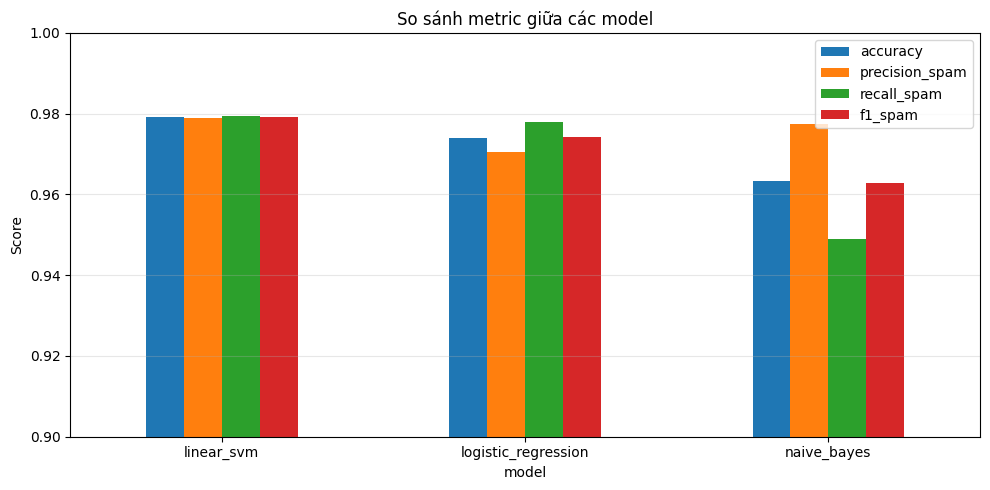

In [8]:
metrics_path = REPORTS_DIR / 'model_metrics.csv'
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics)

    metric_cols = ['accuracy', 'precision_spam', 'recall_spam', 'f1_spam']
    ax = metrics.set_index('model')[metric_cols].plot(kind='bar', figsize=(10, 5), ylim=(0.9, 1.0))
    ax.set_title('So sánh metric giữa các model')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Không tìm thấy reports/model_metrics.csv')


### Nhận xét so sánh model

| Model | Accuracy | Precision spam | Recall spam | F1 spam | Nhận xét |
| --- | ---: | ---: | ---: | ---: | --- |
| Linear SVM | 0.9792 | 0.9790 | 0.9793 | 0.9792 | Tốt nhất tổng thể, precision/recall cân bằng |
| Logistic Regression | 0.9740 | 0.9704 | 0.9778 | 0.9741 | Recall spam cao, nhưng precision thấp hơn SVM |
| Naive Bayes | 0.9634 | 0.9773 | 0.9488 | 0.9629 | Precision tốt nhưng bỏ sót spam nhiều hơn |

Kết luận: Linear SVM là lựa chọn cuối vì có F1 spam cao nhất và giữ cân bằng tốt giữa precision và recall. Nếu mục tiêu cực kỳ ưu tiên tốc độ, Naive Bayes vẫn là baseline tốt. Nếu cần dễ giải thích hơn SVM, Logistic Regression là phương án trung gian.


## 11. Confusion Matrix

Confusion matrix cho biết model sai ở đâu:

- True Negative: email tốt được dự đoán đúng là not spam.
- False Positive: email tốt bị chặn nhầm là spam.
- False Negative: email spam bị bỏ sót.
- True Positive: email spam được phát hiện đúng.

Ảnh grid dưới đây được trích từ `06_model_comparison_charts.ipynb`.

![Grid confusion matrix của các model](../reports/figures/model_confusion_matrix_grid.png)

Các ảnh riêng từng model được sinh từ `src/model_evaluate.py`:

![Linear SVM confusion matrix](../reports/figures/linear_svm_confusion_matrix.png)

![Logistic Regression confusion matrix](../reports/figures/logistic_regression_confusion_matrix.png)

![Naive Bayes confusion matrix](../reports/figures/naive_bayes_confusion_matrix.png)


## 12. Learning Curve

Learning curve cho thấy model thay đổi ra sao khi tăng số lượng mẫu train. Các ảnh dưới đây là kết quả đã train và đã được lấy lại từ quá trình đánh giá model. Đây không phải ảnh mẫu.

- Đường đỏ: F1-score trên tập train.
- Đường xanh: F1-score cross-validation.
- Khoảng cách giữa hai đường càng nhỏ thì model càng ít overfitting.
- Nếu đường xanh còn tăng khi thêm dữ liệu, model vẫn hưởng lợi từ việc mở rộng dataset.

![Learning Curve - Linear SVM](../reports/figures/learning_curve_linear_svm.png)

![Learning Curve - Logistic Regression](../reports/figures/learning_curve_logistic_regression.png)

![Learning Curve - Naive Bayes](../reports/figures/learning_curve_naive_bayes.png)


### Nhận xét learning curve

- Linear SVM và Logistic Regression có đường validation tăng dần khi tăng số lượng mẫu, chứng tỏ thêm data giúp model tổng quát hóa tốt hơn.
- Khoảng cách train-validation vẫn tồn tại nhưng không quá lớn, đặc biệt ở vùng nhiều mẫu.
- Naive Bayes có F1 thấp hơn và dao động hơn, phù hợp làm baseline nhanh nhưng không phải lựa chọn cuối.
- Với mục tiêu 100,000 đến 400,000 mẫu, dữ liệu lớn hơn có thể tiếp tục giúp Linear SVM/Logistic Regression ổn định hơn, miễn là nguồn dữ liệu sạch và nhãn đáng tin cậy.


## 13. Model Selection

Model cuối được chọn: `TF-IDF + Linear SVM`.

Lý do chọn:

- F1 spam cao nhất trong 3 model.
- Accuracy cao nhất.
- Precision spam và recall spam cân bằng, không nghiêng quá mạnh về một phía.
- Phù hợp với bài toán text classification dùng TF-IDF sparse vector.

Trong phần trình bày, có thể nói ngắn gọn:

> Nhóm chọn Linear SVM vì model này đạt F1 spam cao nhất, vừa phát hiện spam tốt vừa giảm nguy cơ chặn nhầm email tốt so với các model còn lại.


## 14. Demo Predict Email mới

Module chính: `src/predict.py`.

Hàm `predict_email()` trả về:

- `prediction`: `spam` hoặc `not spam`.
- `spam_score`: điểm nghiêng về spam trong khoảng 0-1.
- `cleaned_text`: text sau tiền xử lý.
- `evidence`: các dấu hiệu văn bản hỗ trợ giải thích kết quả.


In [9]:
from src.predict import load_pipeline, predict_email

model_path = MODELS_DIR / 'spam_classifier.joblib'
model = load_pipeline(model_path)

demo_emails = [
    'Congratulations winner, claim your free lottery prize money now by clicking this urgent link.',
    'Hi team, please confirm tomorrow meeting agenda and send the project report when ready.',
]

for email_text in demo_emails:
    result = predict_email(email_text, model=model)
    print('Email:', email_text)
    print('Prediction:', result['prediction'])
    print('Spam score:', result['spam_score'])
    print('Cleaned:', result['cleaned_text'])
    print('Evidence keys:', sorted(result.get('evidence', {}).keys()))
    print()


Email: Congratulations winner, claim your free lottery prize money now by clicking this urgent link.
Prediction: spam
Spam score: 0.875827
Cleaned: congratulations winner claim free lottery prize money clicking urgent link
Evidence keys: []

Email: Hi team, please confirm tomorrow meeting agenda and send the project report when ready.
Prediction: not spam
Spam score: 0.220144
Cleaned: hi team please confirm tomorrow meeting agenda send project report ready
Evidence keys: []



## 15. Web UI kiểm tra spam

Project có giao diện Flask tại `app.py`.

Cách chạy:

```powershell
python app.py
```

Sau đó mở:

```text
http://127.0.0.1:5000
```

Lưu ý: không mở trực tiếp file `templates/spam_checker.html` bằng Live Server port `5500`, vì Flask cần render cú pháp Jinja như `{% ... %}` và `{{ ... }}`.

Giao diện trả về:

- Kết quả: spam hoặc not spam.
- Spam score.
- Dẫn chứng vì sao kết quả nghiêng về spam/not spam, dựa trên text đã tiền xử lý và các term ảnh hưởng.


In [10]:
if SAMPLE_EMAILS_DIR.exists():
    print('Các email mẫu để test UI:')
    for path in sorted(SAMPLE_EMAILS_DIR.glob('*.txt')):
        print('-', path.name)
else:
    print('Không tìm thấy sample_emails/')


Các email mẫu để test UI:
- borderline_01_marketing_newsletter.txt
- borderline_02_many_recipients_but_legit.txt
- notspam_01_team_meeting.txt
- notspam_02_assignment_update.txt
- notspam_03_class_reminder.txt
- notspam_04_invoice_normal.txt
- spam_01_prize_claim.txt
- spam_02_account_warning.txt
- spam_03_discount_offer.txt
- spam_04_payment_request.txt


## 16. Code Standard và kiểm soát chất lượng

Project có file kiểm tra naming trong `reports/code_style_name_check.json`.

Rule chính:

| Thành phần | Quy chuẩn |
| --- | --- |
| File Python | chữ thường, snake_case, đuôi `.py` |
| Function/variable | snake_case |
| Constant | UPPER_CASE |
| Class | PascalCase |
| Label | `0 = not spam/ham`, `1 = spam` |

Các file source chính gồm `data_loader.py`, `data_quality.py`, `text_preprocess.py`, `feature_engineering.py`, `model_train.py`, `model_evaluate.py`, `predict.py`, `app.py`.


In [11]:
style_report_path = REPORTS_DIR / 'code_style_name_check.json'
if style_report_path.exists():
    style_report = json.loads(style_report_path.read_text(encoding='utf-8'))
    print(json.dumps(style_report, indent=2, ensure_ascii=False))
else:
    print('Không tìm thấy reports/code_style_name_check.json')


{
  "rule_summary": {
    "files": "ten_file.py dung chu thuong va dau gach duoi",
    "functions_variables": "snake_case",
    "constants": "UPPER_CASE",
    "classes": "PascalCase",
    "labels": "0 = not spam/ham, 1 = spam"
  },
  "files_checked": [
    "config.py",
    "main.py",
    "src/__init__.py",
    "src/data_loader.py",
    "src/data_quality.py",
    "src/feature_engineering.py",
    "src/model_evaluate.py",
    "src/model_train.py",
    "src/predict.py",
    "src/text_preprocess.py",
    "src/utils.py"
  ],
  "naming_issues": []
}


## 17. Kết luận cuối

Pipeline cuối cùng đã có đủ các phần:

- Xác định bài toán và tiêu chí đánh giá.
- Thu thập dữ liệu từ các nguồn public/chính thống hoặc cộng đồng đáng kiểm tra.
- Gộp dữ liệu, kiểm tra chất lượng và cân bằng nhãn.
- EDA bằng biểu đồ phân bố nhãn và độ dài email.
- Tiền xử lý text để giảm nhiễu và chuẩn hóa các dấu hiệu như URL/email/số.
- Feature engineering bằng TF-IDF.
- Train và so sánh Naive Bayes, Logistic Regression, Linear SVM.
- Đánh giá bằng accuracy, precision, recall, F1-score, confusion matrix và learning curve.
- Chọn Linear SVM làm model cuối vì F1 spam tốt nhất và cân bằng precision/recall.
- Dự đoán email mới bằng model đã train.
- Giao diện web local để kiểm tra email spam/not spam.

Khi thuyết trình, nhóm nên nhấn mạnh rằng kết quả dự đoán dựa trên đặc trưng văn bản đã học từ dataset, không phải rule thủ công. Dẫn chứng spam/not spam nên lấy từ score, text sau tiền xử lý và các term ảnh hưởng thay vì chỉ nói tên model.


## 18. Checklist trình bày

- Giới thiệu bài toán: phân loại spam/not spam.
- Nói rõ label: `0` là not spam, `1` là spam.
- Trình bày nguồn dữ liệu và lý do cần nguồn đáng tin cậy.
- Giải thích vì sao phải cân bằng dữ liệu.
- Trình bày preprocessing và TF-IDF.
- So sánh 3 model bằng bảng metric.
- Giải thích confusion matrix: TN, FP, FN, TP.
- Giải thích learning curve: train score, validation score, overfitting.
- Kết luận Linear SVM tốt nhất theo F1 spam.
- Demo giao diện: nhập email, nhận kết quả, đọc spam score và dẫn chứng.
